## Тест работы espaloma_charge

In [5]:
import glob
import os
import sys
# import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
import IPython.display as display
from io import BytesIO
import base64

from rdkit import Chem
from rdkit.Chem import AllChem, Draw, rdFMCS
import json
sys.path.append(os.path.abspath("../espaloma-charge_mod/"))
# sys.path.append(os.path.abspath("../espaloma-charge/"))

from espaloma_charge import charge
# import param_tool as pt

### Доп функции 

In [4]:
def mol2_to_chem(path_to_mol2, sanitize=True, removeHs=False):
    rdkit_chem = Chem.MolFromMol2File(path_to_mol2, sanitize=sanitize, removeHs=removeHs)
    if rdkit_chem:
        AllChem.Compute2DCoords(rdkit_chem)
    return rdkit_chem

In [5]:
def draw_mol_with_atom_index(mol, charge_list=None, size=(600, 400)):
    """
    Добавляет номера атомов в атрибуты атомов молекулы и рисует молекулу.
    """
    if charge_list is not None and len(charge_list) == len(mol.GetAtoms()):
        for i, atom in enumerate(mol.GetAtoms()):
            atom.SetAtomMapNum(atom.GetIdx())
            atom.SetDoubleProp('PartialCharge', float(charge_list[i]))  # Преобразование в float
            atom.SetProp('atomNote', str(f"{charge_list[i]:.4f}"))
    else:
        for i, atom in enumerate(mol.GetAtoms()):
            atom.SetAtomMapNum(atom.GetIdx())

    return Draw.MolToImage(mol, size)

In [6]:
def get_name(path: str, index=0):
    """
    Аргумент: 
        path - строка с путем к файлу
    Возвращает:
        Имя для ключа в словаре 
    """
    # Сохраняем текущий stderr
    original_stderr = sys.stderr
    try:
        sys.stderr = open(os.devnull, 'w')
        mol = Chem.MolFromSmiles(path)
        if mol:
            return index
        else:
            name_of_file = os.path.basename(path).split('.')[0]
            return name_of_file
    except Exception as e:
        print(f"Ошибка при обработке '{path}': {e}")
        return None
    finally:
        # Возвращаем stderr на исходное место
        sys.stderr = original_stderr
        
def data_to_dict(funсtion):
    '''
    Декоратор для обработки данных различного типа (строка, список, словарь) перед вызовом функции.
    '''
    def wrapper(data: str or list[str] or dict[str, str], **kwarg):
        if isinstance(data, str):
            return {get_name(data): funсtion(data, **kwarg)}
        elif isinstance(data, list):
            return {get_name(str_data, i):funсtion(str_data, **kwarg) for i, str_data in enumerate(data)}
        elif isinstance(data, dict):
            return {legend: funсtion(str_data, **kwarg) for legend, str_data in data.items()}
        else:
            print('Некорректный тип данных ввода', file=sys.stderr)
            return None
    return wrapper

@data_to_dict
def read_file(path):
    '''
    Читает первую строку из файла и возвращает её.
    '''
    with open (path, 'r') as f:
        return f.readline().strip()

# @data_to_dict
def smi_to_chem(str_smi: str, sanitize=True, addH=True, make_N_root=False):
    """
    Преобразует SMILES-строку в объект молекулы RDKit и добавляет атомы водорода.
    """
    rdkit_mol = Chem.MolFromSmiles(str_smi, sanitize) # переводим во внутренний формат chem
    if addH:
        rdkit_mol = Chem.AddHs(rdkit_mol) # протонируем
        
    # Перенумерация атомов, деля аминогруппу началом молекулы
    if make_N_root:
        # Находим индекс азота из аминогруппы
        root_idx = find_amino_nitrogen(rdkit_mol)
        if root_idx != -1:
            # Получаем SMILES с корневым атомом
            smiles_string = Chem.MolToSmiles(rdkit_mol, canonical=True, allHsExplicit=True, rootedAtAtom=root_idx)
            # Создаем новую молекулу из SMILES
            rdkit_mol = Chem.MolFromSmiles(smiles_string, sanitize=False)
            if rdkit_mol is None:
                raise ValueError("Ошибка при создании молекулы после перенумерации атомов")
        else:
            print("Азот аминогруппы не найден. Корень не изменён.")
        # Chem.SanitizeMol(rdkit_mol, sanitizeOps=Chem.SANITIZE_ALL ^ Chem.SANITIZE_KEKULIZE, catchErrors=True)
        Chem.SanitizeMol(rdkit_mol)
        
    # Сортируем атомы, чтобы тяжелые атомы шли первыми, а водороды позже
        atom_order = [atom.GetIdx() for atom in rdkit_mol.GetAtoms() if atom.GetSymbol() != 'H']  # тяжелые атомы
        atom_order += [atom.GetIdx() for atom in rdkit_mol.GetAtoms() if atom.GetSymbol() == 'H']  # водороды
    
    # Перенумерация атомов согласно новому порядку
        new_rdkit_mol = Chem.RenumberAtoms(rdkit_mol, atom_order)
        # Пересчитываем валентности
        return new_rdkit_mol
    else:
        return rdkit_mol

### Тестирование работы 

In [2]:
charge

<function espaloma_charge.app.charge(molecule, total_charge: float = None, model_url: str = None, constraints: Dict[int, float] = None) -> numpy.ndarray>

In [3]:
# molecule = Chem.MolFromSmiles("[H][C@@]12CC[C@H](N1C(=O)C2)C([O-])=O")
molecule = Chem.MolFromSmiles('CCO')
ans = charge(molecule)
print(ans)

/home/n_kristovsky/.conda/envs/espaloma/lib/python3.9/site-packages/dgl/heterograph.py:92: DGLWarning: Recommend creating graphs by `dgl.graph(data)` instead of `dgl.DGLGraph(data)`.
  dgl_warning(


[-0.2975962  0.8130467 -0.5154505]


In [4]:
# molecule = Chem.MolFromSmiles("[H][C@@]12CC[C@H](N1C(=O)C2)C([O-])=O")
mol = Chem.MolFromSmiles('CCO')

# Фиксируем заряды для атомов 0 и 2
fixed = {0: 0.1, 2: -0.2}  
charges = charge(mol, 
                 constraints=fixed
                )

print(charges)

Graph(num_nodes=3, num_edges=4,
      ndata_schemes={'type': Scheme(shape=(1,), dtype=torch.float32), 'q_ref': Scheme(shape=(1,), dtype=torch.float32), 'h0': Scheme(shape=(116,), dtype=torch.float32), 'h': Scheme(shape=(128,), dtype=torch.float32), 'e': Scheme(shape=(1,), dtype=torch.float32), 's': Scheme(shape=(1,), dtype=torch.float32)}
      edata_schemes={})
[ 0.1         0.10000002 -0.2       ]


## Расчет зарядов для 10 аминокислот

In [7]:
mol_list = glob.glob('molecules/*')
mol_list

['molecules/Lysine_Malonyl_rn_3D.pdb',
 'molecules/Lysine_Crotonyl_rn_3D.pdb',
 'molecules/Lysine_2M_rn_3D.pdb',
 'molecules/Lysine_Formyl_rn_3D.pdb',
 'molecules/Lysine_1M_rn_3D.pdb',
 'molecules/Lysine_1M_ACC_rn_3D.pdb',
 'molecules/Lysine_Propionyl_rn_3D.pdb',
 'molecules/Lysine_Acetyl_rn_3D.pdb',
 'molecules/Lysine_3M_rn_3D.pdb',
 'molecules/Lysine_Butyryl_rn_3D.pdb']

In [ ]:
for mol in mol_list:
    

In [8]:
test_path_list = glob.glob('demo/*/*.mol2')

In [13]:
n=110
test_chem = mol2_to_chem(test_path_list[n])

In [18]:
name = '1lpg'
path = glob.glob(f'demo/*/{name}*.mol2')
path
test_chem = mol2_to_chem(*path)

In [32]:
test_smi= read_file('../param_R_CIT/moleculse/Lysine_3M.smiles')
test_chem = smi_to_chem(test_smi)

In [33]:
test_chem

{'Lysine_3M': <rdkit.Chem.rdchem.Mol at 0x7fa25f493120>}

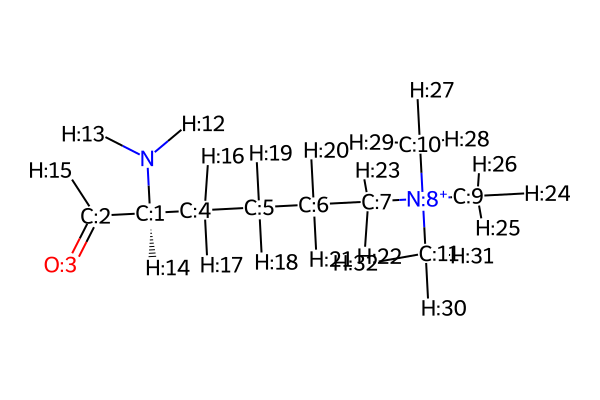

In [35]:
draw_mol_with_atom_index(test_chem['Lysine_3M'])

In [36]:
charge_list = list(charge(test_chem['Lysine_3M']))
print(f'{charge_list} \n {sum(charge_list)}')

[-0.9895772, -0.124787115, 0.62304926, -0.58458245, -0.14538103, -0.15344676, -0.16276518, 0.052145533, -0.671685, 0.0064276904, 0.0064276904, 0.0064276904, 0.36258623, 0.36258623, 0.05954788, 0.01648558, 0.07235828, 0.07235828, 0.069499515, 0.069499515, 0.072254024, 0.072254024, 0.0816883, 0.0816883, 0.08277117, 0.08277117, 0.08277117, 0.08277117, 0.08277117, 0.08277117, 0.08277117, 0.08277117, 0.082771175] 
 -1.564621925354004e-07


/home/n_kristovsky/.conda/envs/ai_topmol/lib/python3.9/site-packages/dgl/heterograph.py:92: DGLWarning: Recommend creating graphs by `dgl.graph(data)` instead of `dgl.DGLGraph(data)`.
  dgl_warning(


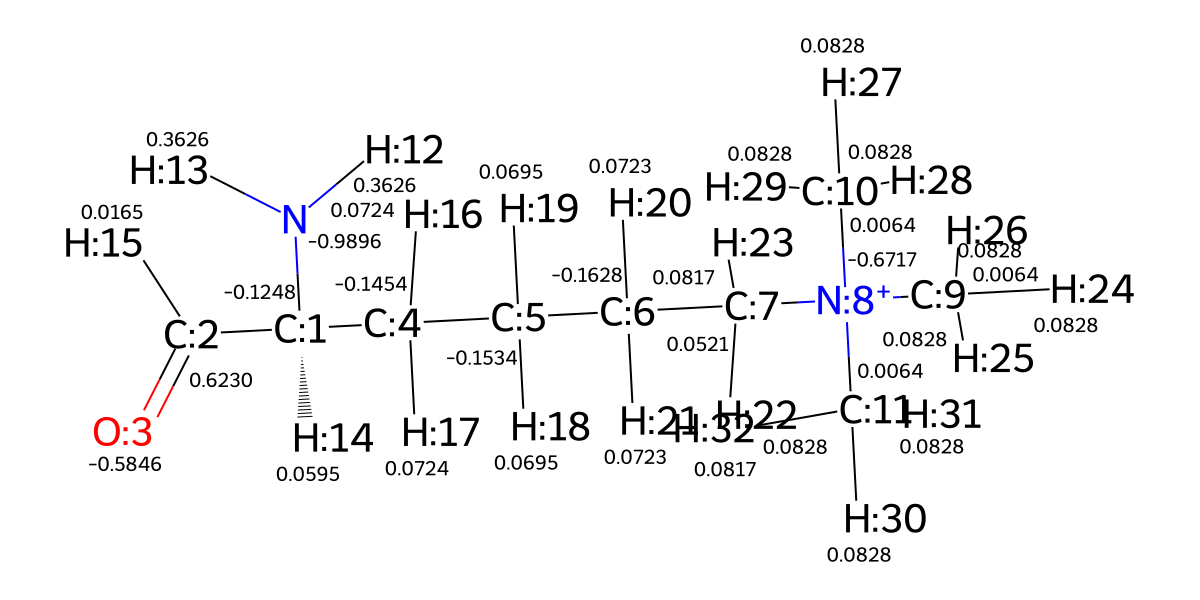

In [37]:
draw_mol_with_atom_index(test_chem['Lysine_3M'], charge_list=charge_list, size=(1200,600))

In [22]:
charge_list[29]

-0.55895287

In [8]:
SMILES = "[H]N([H])[C@]([H])(C(=O)N([H])[C@]([H])(C(=O)N([H])[C@]([H])(C([H])=O)C([H])([H])[H])C([H])([H])C([H])([H])C([H])([H])C([H])([H])[N+](C([H])([H])[H])(C([H])([H])[H])C([H])([H])[H])C([H])([H])[H]"

In [9]:
from rdkit import Chem
molecule = Chem.MolFromSmiles(SMILES)
molecule = Chem.AddHs(molecule)

In [33]:
from espaloma_charge import charge
charge_list = list(charge(molecule))
print(f'{charge_list} \n {sum(charge_list)}')

[-0.97515535, 0.019805903, 0.67799014, -0.7639928, -0.50520945, -0.0073070284, 0.6819243, -0.79268503, -0.49795267, -0.114077285, 0.6156056, -0.58183277, -0.12693505, -0.14208202, -0.15348694, -0.15814862, 0.058345005, -0.66158104, 0.0135713015, 0.0135713015, 0.0135713015, -0.1676676, 0.38024318, 0.38024318, 0.06702723, 0.30957016, 0.08905143, 0.3176582, 0.06463857, 0.020060262, 0.05143141, 0.05143141, 0.05143141, 0.07900851, 0.07900851, 0.08014975, 0.08014975, 0.08555391, 0.08555391, 0.09489557, 0.09489557, 0.10083699, 0.10083699, 0.10083699, 0.10083699, 0.10083699, 0.10083699, 0.10083699, 0.10083699, 0.10083699, 0.061398327, 0.061398327, 0.061398327] 
 1.0281801223754883e-06


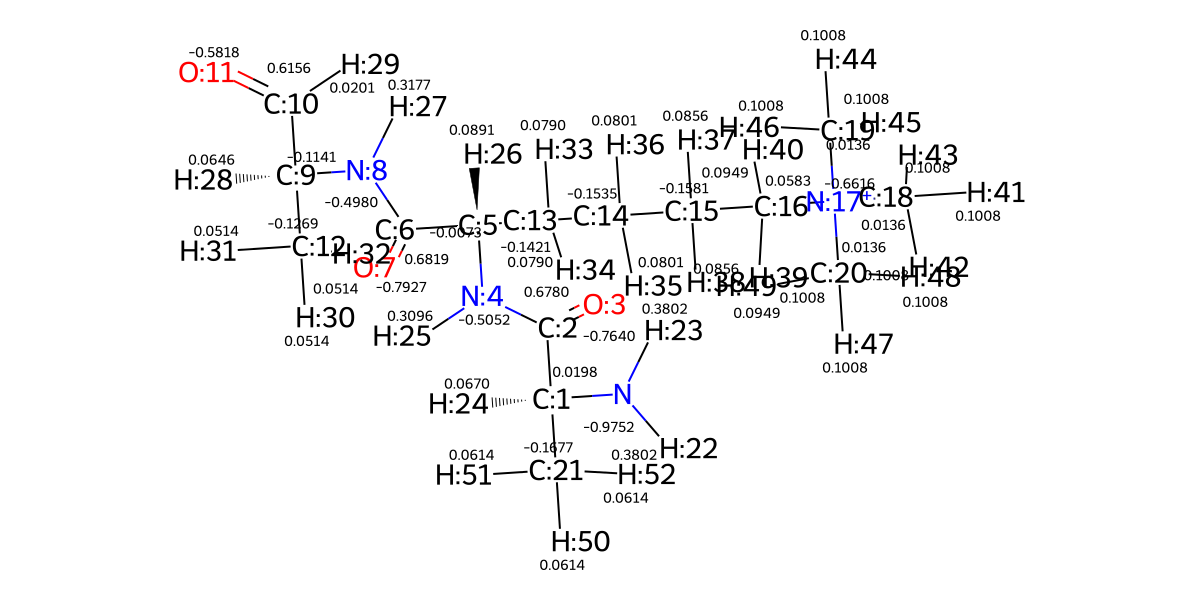

In [36]:
draw_mol_with_atom_index(molecule, charge_list=charge_list, size=(1200,600))

In [21]:
len(charge_list)

53

In [24]:
molecule.GetNumAtoms()

53

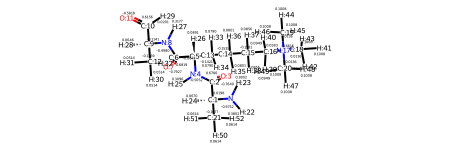

In [37]:
molecule

## Работы с QCArchive

In [1]:
import qcportal as ptl

client = ptl.PortalClient("https://qcademo.molssi.org")
print(client)

PortalClient(server_name='MolSSI QCFractal Demo Server', address='https://qcademo.molssi.org/', username='None')


In [2]:
first_record = client.get_records(1)
print(first_record)

<SinglepointRecord id=1 status=complete>


In [4]:
print(first_record.properties["scf_two_electron_energy"])

0.6644901039732637


## Расчет зарядов для тестового набора ChEBI_30

In [6]:
ChEBI_30 = pd.read_csv('ChEBI_30_from_15K.csv')
mol_name = glob.glob('RESP_data/*')
RESP_done = [name.replace('RESP_data/','') for name in mol_name]
ChEBI_30[:5]

FileNotFoundError: [Errno 2] No such file or directory: 'ChEBI_30_from_15K.csv'

In [85]:
for resp_done in RESP_done:
    smiles = str(*ChEBI_30[ChEBI_30['Molecule_Name'].str.contains(resp_done)]['smiles'].tolist())
    # print(smiles)
    test_chem = smi_to_chem(smiles)
    # draw_mol_with_atom_index(test_chem[0])
    charge_list = list(charge(test_chem[0]))
    rounded_list = [round(float(x), 4) for x in charge_list]
    print(f'{resp_done} \n {rounded_list} \n {sum(rounded_list)}')
    with open(f'RESP_data/{resp_done}/{resp_done}_charge_list_Espaloma.json', 'w') as convert_file:
        convert_file.write(json.dumps(list(rounded_list)))

CHEBI:58340 
 [-0.2552, 0.8071, -0.4974, -0.4899, 0.1878, -0.3156, -0.7611, 0.9598, -0.7678, -0.7686, 0.1145, 0.1145, 0.1145, 0.1101, 0.1101, 0.16, 0.3924, 0.3924, 0.3924] 
 3.3306690738754696e-16
CHEBI:67010 
 [-0.9107, -0.1895, -0.2299, 0.7533, -0.5258, -0.3913, -0.0222, -0.2107, -0.0522, -0.4082, 0.3134, -0.8093, 0.9803, -0.7397, -0.734, 0.4331, 0.4331, 0.1282, 0.1539, 0.1539, 0.259, 0.2635, 0.2713, 0.2687, 0.4059, 0.4059] 
 5.551115123125783e-16
CHEBI:63137 
 [-0.7144, 0.1849, 0.065, -0.7108, -0.2899, -0.175, 0.9671, -0.7714, -0.781, 0.4251, 0.1184, 0.1956, 0.1956, 0.3951, 0.3951, 0.1781, 0.1614, 0.1614] 
 0.00029999999999985594
CHEBI:84913 
 [-0.6631, 0.7799, -0.6411, -0.0968, -0.1901, -0.0909, 0.7556, -0.6455, -0.4626, -0.3036, 0.0855, -0.7807, 0.951, -0.7799, -0.7851, 0.324, 0.324, 0.156, 0.1533, 0.3524, 0.1129, 0.1814, 0.1814, 0.3606, 0.3606, 0.3606] 
 -0.000200000000000089
CHEBI:58080 
 [-0.2492, 0.7618, -0.6934, -0.4952, 0.058, 0.0966, -0.6939, 0.1314, -0.6955, 0.0902, 0.11, 

## Расчет зарядов для тестового набора ChEBI_100

In [7]:
ChEBI_100 = pd.read_csv('../datasets/ChEBI_100_from_15K.csv')
ChEBI_100[:5]

,Unnamed: 0,Molecule_Name,2D_Image,smiles,Has_Charged_Atoms,Total_Charge,Num_Atoms,Atom_Types
0,0,CHEBI:138619,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",N1(C=2C(=C(N=CN2)N)N=C1)[C@@H]3O[C@H](COP([O-]...,True,0,28,"C,N,O,P"
1,1,CHEBI:57511,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",[H][C@]12SCC(COC(C)=O)=C(N1C(=O)[C@H]2NC(=O)CC...,True,-1,28,"C,N,O,S"
2,2,CHEBI:65070,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",[NH3+]CCC[NH2+]CC[C@H]([NH3+])C([O-])=O,True,2,12,"C,N,O"
3,3,CHEBI:73939,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",[H][C@@]12CC[C@H](N1C(=O)C2)C([O-])=O,True,-1,11,"C,N,O"
4,4,CHEBI:63137,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",OC1C[NH2+]C(C1)C([O-])=O,True,0,9,"C,N,O"


In [8]:
from openff.toolkit.topology import Molecule
from espaloma_charge.openff_wrapper import EspalomaChargeToolkitWrapper
import espaloma_charge
from espaloma_charge import charge
smi = 'OC1C[NH2+]C(C1)C([O-])=O'
toolkit_registry = EspalomaChargeToolkitWrapper()

# Добавляем allow_undefined_stereo=True
molecule = Molecule.from_smiles(smi, allow_undefined_stereo=True)
molecule.assign_partial_charges('espaloma-am1bcc', toolkit_registry=toolkit_registry)
print(molecule.partial_charges)


[-0.7144431372483572 0.1849475602308909 0.0649544099966685 -0.7108470698197683 -0.2899117370446523 -0.17495072384675345 0.9670982460180918 -0.7714061637719473 -0.7810001273949941 0.4251025716463725 0.11836397151152293 0.1955587069193522 0.19555864731470743 0.3950975338617961 0.3950975338617961 0.17807603875796 0.161351869503657 0.161351869503657] elementary_charge


/home/n_kristovsky/.conda/envs/ai_topmol/lib/python3.9/site-packages/dgl/heterograph.py:92: DGLWarning: Recommend creating graphs by `dgl.graph(data)` instead of `dgl.DGLGraph(data)`.
  dgl_warning(


In [16]:
import pandas as pd
from openff.toolkit.topology import Molecule
from espaloma_charge.openff_wrapper import EspalomaChargeToolkitWrapper
from rdkit import Chem
from espaloma_charge import charge
from decimal import Decimal, getcontext
from pint import UnitRegistry

ureg = UnitRegistry()  # Инициализация UnitRegistry для работы с единицами измерения

def calculate_charges_openff(df, toolkit_registry):
    """
    Функция рассчитывает частичные заряды атомов для каждой молекулы в DataFrame
    с использованием OpenFF Toolkit и Espaloma AM1BCC.

    :param df: DataFrame с колонкой 'smiles'.
    :param toolkit_registry: Экземпляр EspalomaChargeToolkitWrapper.
    :return: DataFrame с добавленными колонками 'espaloma_charges' и 'espaloma_total_charge'.
    """
    espaloma_charges = []
    espaloma_total_charges = []
    
    for index, row in df.iterrows():
        smiles = row['smiles']
        
        try:
            # Создаем молекулу из SMILES
            molecule = Molecule.from_smiles(smiles, allow_undefined_stereo=True)
            
            # Назначаем частичные заряды с использованием espaloma_am1bcc
            molecule.assign_partial_charges('espaloma-am1bcc', toolkit_registry=toolkit_registry)
            
            # Получаем список частичных зарядов
            charges = molecule.partial_charges
            # Удаляем единицы измерения и приводим к float
            espaloma_charges.append([float(q.magnitude) for q in charges])  
            
            # Суммируем частичные заряды с использованием Decimal
            total_charge = round(sum(Decimal(str(q.magnitude)) for q in charges), 1)
            espaloma_total_charges.append(total_charge)  # Округленное значение
        except Exception as e:
            print(f"Ошибка при расчете зарядов для {index}: {e}")
            espaloma_charges.append(None)
            espaloma_total_charges.append(None)
    
    # Присваивание новых колонок должно происходить правильно
    df.loc[:, 'openff_charges'] = espaloma_charges
    df.loc[:, 'openff_total_charge'] = espaloma_total_charges
    
    return df

def calculate_charges_rdkit(df):
    """
    Функция рассчитывает частичные заряды атомов для каждой молекулы в DataFrame
    с использованием RDKit и Espaloma Charge.

    :param df: DataFrame с колонкой 'smiles'.
    :return: DataFrame с добавленными колонками 'rdkit_charges' и 'rdkit_total_charge'.
    """
    rdkit_charges = []
    rdkit_total_charges = []
    
    for index, row in df.iterrows():
        smiles = row['smiles']
        
        try:
            # Создаем молекулу из SMILES
            molecule = smi_to_chem(smiles, )
            
            # Рассчитываем частичные заряды
            charges = charge(molecule)
            rdkit_charges.append([float(c) for c in charges])  # Приводим к float
            
            # Суммируем частичные заряды с использованием Decimal
            total_charge = round(sum(Decimal(str(c)) for c in charges), 1)
            rdkit_total_charges.append(total_charge)  # Округленное значение
        except Exception as e:
            print(f"Ошибка при расчете зарядов для {index}: {e}")
            rdkit_charges.append(None)
            rdkit_total_charges.append(None)
    
    # Присваивание новых колонок должно происходить правильно
    df.loc[:, 'rdkit_charges'] = rdkit_charges
    df.loc[:, 'rdkit_total_charge'] = rdkit_total_charges
    
    return df

# Чтение CSV-файла
df = pd.read_csv('../datasets/ChEBI_100_from_15K.csv')

# Создаем экземпляр EspalomaChargeToolkitWrapper
toolkit_registry = EspalomaChargeToolkitWrapper()

# Расчет зарядов методом OpenFF Toolkit + Espaloma AM1BCC
df = calculate_charges_openff(df, toolkit_registry)

# Расчет зарядов методом RDKit + Espaloma Charge
df = calculate_charges_rdkit(df)

# Вывод первых пяти строк DataFrame
df.head()

/home/n_kristovsky/.conda/envs/ai_topmol/lib/python3.9/site-packages/dgl/heterograph.py:92: DGLWarning: Recommend creating graphs by `dgl.graph(data)` instead of `dgl.DGLGraph(data)`.
  dgl_warning(
/home/n_kristovsky/.conda/envs/ai_topmol/lib/python3.9/site-packages/dgl/heterograph.py:92: DGLWarning: Recommend creating graphs by `dgl.graph(data)` instead of `dgl.DGLGraph(data)`.
  dgl_warning(


,Unnamed: 0,Molecule_Name,2D_Image,smiles,Has_Charged_Atoms,Total_Charge,Num_Atoms,Atom_Types,openff_charges,openff_total_charge,rdkit_charges,rdkit_total_charge
0,0,CHEBI:138619,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",N1(C=2C(=C(N=CN2)N)N=C1)[C@@H]3O[C@H](COP([O-]...,True,0,28,"C,N,O,P","[-0.3177318626895864, 0.370638573740391, -0.22...",-0.0,"[-0.3810335099697113, 0.4075903296470642, -0.2...",-0.0
1,1,CHEBI:57511,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",[H][C@]12SCC(COC(C)=O)=C(N1C(=O)[C@H]2NC(=O)CC...,True,-1,28,"C,N,O,S","[0.11585277844763671, -0.010888950297764193, -...",-1.0,"[0.009944342076778412, -0.08738074451684952, -...",-0.0
2,2,CHEBI:65070,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",[NH3+]CCC[NH2+]CC[C@H]([NH3+])C([O-])=O,True,2,12,"C,N,O","[-0.7403258279927315, 0.026825475596612497, -0...",2.0,"[-0.804841935634613, -0.03769063204526901, -0....",0.0
3,3,CHEBI:73939,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",[H][C@@]12CC[C@H](N1C(=O)C2)C([O-])=O,True,-1,11,"C,N,O","[0.12330305542012579, -0.05910514422545308, -0...",-1.0,"[-0.0064735738560557365, -0.13554397225379944,...",0.0
4,4,CHEBI:63137,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",OC1C[NH2+]C(C1)C([O-])=O,True,0,9,"C,N,O","[-0.7144431372483572, 0.1849475602308909, 0.06...",-0.0,"[-0.7144431471824646, 0.18494755029678345, 0.0...",-0.0


In [17]:
def get_index_charge_atoms(chem):
    N_list = []
    O_list = []
    C_list = []
    H_list = []
    for atom in chem.GetAtoms():
        atom_charge = atom.GetFormalCharge()
        atom_name = atom.GetSymbol()
        if atom_charge < 0 and atom_name == 'O':
            O_list.append(atom.GetIdx())
        elif atom_charge > 0 and atom_name == 'N' :
            N_list.append(atom.GetIdx())
        elif atom_name == 'C':
            C_list.append(atom.GetIdx())
        elif atom_name == 'H':
            H_list.append(atom.GetIdx())
    if not len(N_list):
        N_list = False
    if not len(O_list):
        O_list = False
    if not len(C_list):
        C_list = False
    if not len(H_list):
        H_list = False
    return N_list, O_list, C_list, H_list

# Применяем функцию к каждому SMILES из нашего датафрейма
N_list = []
O_list = []
C_list = []
H_list = []

for idx, row in df.iterrows():
    smiles = row['smiles']
    mol_chem = smi_to_chem(smiles)
    N, O, C, H = get_index_charge_atoms(mol_chem)
    N_list.append(N)
    O_list.append(O)
    C_list.append(C)
    H_list.append(H)

# Добавляем колонки в датафрейм
df['N_indices'] = N_list
df['O_indices'] = O_list
df['C_indices'] = C_list
df['H_indices'] = H_list

# Извлекаем значения зарядов для заряженных атомов азота и кислорода
N_OPENFF = []
N_RDKIT = []
O_OPENFF = []
O_RDKIT = []
C_OPENFF = []
C_RDKIT = []
H_OPENFF = []
H_RDKIT = []

for index, row in df.iterrows():
    N_indices = row['N_indices']
    O_indices = row['O_indices']
    C_indices = row['C_indices']
    H_indices = row['H_indices']
    openff_charges = row['openff_charges']
    rdkit_charges = row['rdkit_charges']
    
    if N_indices:
        N_OPENFF.append([openff_charges[idx] for idx in N_indices])
        N_RDKIT.append([rdkit_charges[idx] for idx in N_indices])
    else:
        N_OPENFF.append(False)
        N_RDKIT.append(False)
    
    if O_indices:
        O_OPENFF.append([openff_charges[idx] for idx in O_indices])
        O_RDKIT.append([rdkit_charges[idx] for idx in O_indices])
    else:
        O_OPENFF.append(False)
        O_RDKIT.append(False)
    
    if C_indices:
        C_OPENFF.append([openff_charges[idx] for idx in C_indices])
        C_RDKIT.append([rdkit_charges[idx] for idx in C_indices])
    else:
        C_OPENFF.append(False)
        C_RDKIT.append(False)
    
    if H_indices:
        H_OPENFF.append([openff_charges[idx] for idx in H_indices])
        H_RDKIT.append([rdkit_charges[idx] for idx in H_indices])
    else:
        H_OPENFF.append(False)
        H_RDKIT.append(False)

# Добавляем колонки с зарядами заряженных атомов в датафрейм
df['N_OPENFF'] = N_OPENFF
df['N_RDKIT'] = N_RDKIT
df['O_OPENFF'] = O_OPENFF
df['O_RDKIT'] = O_RDKIT
df['C_OPENFF'] = C_OPENFF
df['C_RDKIT'] = C_RDKIT
df['H_OPENFF'] = H_OPENFF
df['H_RDKIT'] = H_RDKIT

In [18]:
df.head()

,Unnamed: 0,Molecule_Name,2D_Image,smiles,Has_Charged_Atoms,Total_Charge,Num_Atoms,Atom_Types,openff_charges,openff_total_charge,...,C_indices,H_indices,N_OPENFF,N_RDKIT,O_OPENFF,O_RDKIT,C_OPENFF,C_RDKIT,H_OPENFF,H_RDKIT
0,0,CHEBI:138619,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",N1(C=2C(=C(N=CN2)N)N=C1)[C@@H]3O[C@H](COP([O-]...,True,0,28,"C,N,O,P","[-0.3177318626895864, 0.370638573740391, -0.22...",-0.0,...,"[1, 2, 3, 5, 9, 10, 12, 13, 18, 19, 20, 24, 25]","[28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 3...",[-0.8010073358074148],[-0.8003097176551819],[-0.6830862218395193],[-0.6819493770599365],"[0.370638573740391, -0.22015072944316458, 0.58...","[0.4075903296470642, -0.2008173167705536, 0.63...","[0.1581115370735209, 0.2791086083396952, 0.279...","[0.16235259175300598, 0.28193721175193787, 0.2..."
1,1,CHEBI:57511,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",[H][C@]12SCC(COC(C)=O)=C(N1C(=O)[C@H]2NC(=O)CC...,True,-1,28,"C,N,O,S","[0.11585277844763671, -0.010888950297764193, -...",-1.0,...,"[0, 2, 3, 4, 6, 7, 9, 11, 13, 15, 17, 18, 19, ...","[28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 3...",[-0.3347511685957822],[-0.7579445242881775],"[0.9353608988652317, 0.9394903682599155]","[-0.7787636518478394, -0.7190757989883423]","[0.11585277844763671, -0.1082140527238759, -0....","[0.009944342076778412, -0.05742091313004494, 0...","[-0.7031725145449551, 0.08773747612334167, 0.0...","[0.1366860717535019, 0.10857079178094864, 0.10..."
2,2,CHEBI:65070,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",[NH3+]CCC[NH2+]CC[C@H]([NH3+])C([O-])=O,True,2,12,"C,N,O","[-0.7403258279927315, 0.026825475596612497, -0...",2.0,...,"[1, 2, 3, 5, 6, 7, 9]","[12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 2...","[-0.7403258279927315, -0.7224672631390633, -0....","[-0.804841935634613, -0.7869833707809448, -0.7...",[-0.8668714360364022],[-0.9313875436782837],"[0.026825475596612497, -0.11933961967306753, 0...","[-0.03769063204526901, -0.18385572731494904, 0...","[0.3989900155894218, 0.3989900155894218, 0.398...","[0.3344739079475403, 0.3344739079475403, 0.334..."
3,3,CHEBI:73939,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",[H][C@@]12CC[C@H](N1C(=O)C2)C([O-])=O,True,-1,11,"C,N,O","[0.12330305542012579, -0.05910514422545308, -0...",-1.0,...,"[0, 1, 2, 3, 5, 7, 8]","[11, 12, 13, 14, 15, 16, 17, 18]",False,False,[0.9214085039045465],[-0.730994701385498],"[0.12330305542012579, -0.05910514422545308, -0...","[-0.0064735738560557365, -0.13554397225379944,...","[-0.78427955542544, 0.09881639446278936, 0.098...","[0.17593464255332947, 0.15144793689250946, 0.1..."
4,4,CHEBI:63137,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",OC1C[NH2+]C(C1)C([O-])=O,True,0,9,"C,N,O","[-0.7144431372483572, 0.1849475602308909, 0.06...",-0.0,...,"[1, 2, 4, 5, 6]","[9, 10, 11, 12, 13, 14, 15, 16, 17]",[-0.7108470698197683],[-0.7108470797538757],[-0.7714061637719473],[-0.7714061737060547],"[0.1849475602308909, 0.0649544099966685, -0.28...","[0.18494755029678345, 0.06495440006256104, -0....","[0.4251025716463725, 0.11836397151152293, 0.19...","[0.425102561712265, 0.11836396157741547, 0.195..."


In [19]:
pd.set_option('display.max_columns', None)  # Показать все колонки
pd.set_option('display.width', 150)  # Увеличить ширину консоли для длинных строк
pd.set_option('display.precision', 4)  # Ограничить количество знаков после запятой

# Вывод данных без индексов строк
print(df[['Total_Charge', 'openff_total_charge', 'rdkit_total_charge']].to_string(index=False))

 Total_Charge openff_total_charge rdkit_total_charge
            0                -0.0               -0.0
           -1                -1.0               -0.0
            2                 2.0                0.0
           -1                -1.0                0.0
            0                -0.0               -0.0
            0                 0.0                0.0
            2                 2.0                0.0
           -2                -2.0               -0.0
           -3                -3.0                0.0
            0                 0.0                0.0
           -1                -1.0               -0.0
           -1                -1.0                0.0
           -3                -3.0               -0.0
           -1                -1.0                0.0
            0                -0.0               -0.0
            0                 0.0               -0.0
           -1                -1.0                0.0
            0                -0.0             

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
N_RDKIT_list = []
N_openff_list = []

O_RDKIT_list = []
O_openff_list = []

C_RDKIT_list = []
C_openff_list = []

H_RDKIT_list = []
H_openff_list = []
for mol_n in df['N_OPENFF']:
    if mol_n:
        for N in mol_n:
            N_openff_list.append(N)
for mol_n in df['N_RDKIT']:
    if mol_n:
        for N in mol_n:
            N_RDKIT_list.append(N)
            
for mol_o in df['O_OPENFF']:
    if mol_o:
        for O in mol_o:
            O_openff_list.append(O)
for mol_o in df['O_RDKIT']:
    if mol_o:
        for O in mol_o:
            O_RDKIT_list.append(O)
            
for mol_c in df['C_OPENFF']:
    if mol_c:
        for C in mol_c:
            C_openff_list.append(C)
for mol_c in df['C_RDKIT']:
    if mol_c:
        for C in mol_c:
            C_RDKIT_list.append(C)
            
for mol_H in df['H_OPENFF']:
    if mol_H:
        for H in mol_H:
            H_openff_list.append(H)
for mol_H in df['H_RDKIT']:
    if mol_H:
        for H in mol_H:
            H_RDKIT_list.append(H)


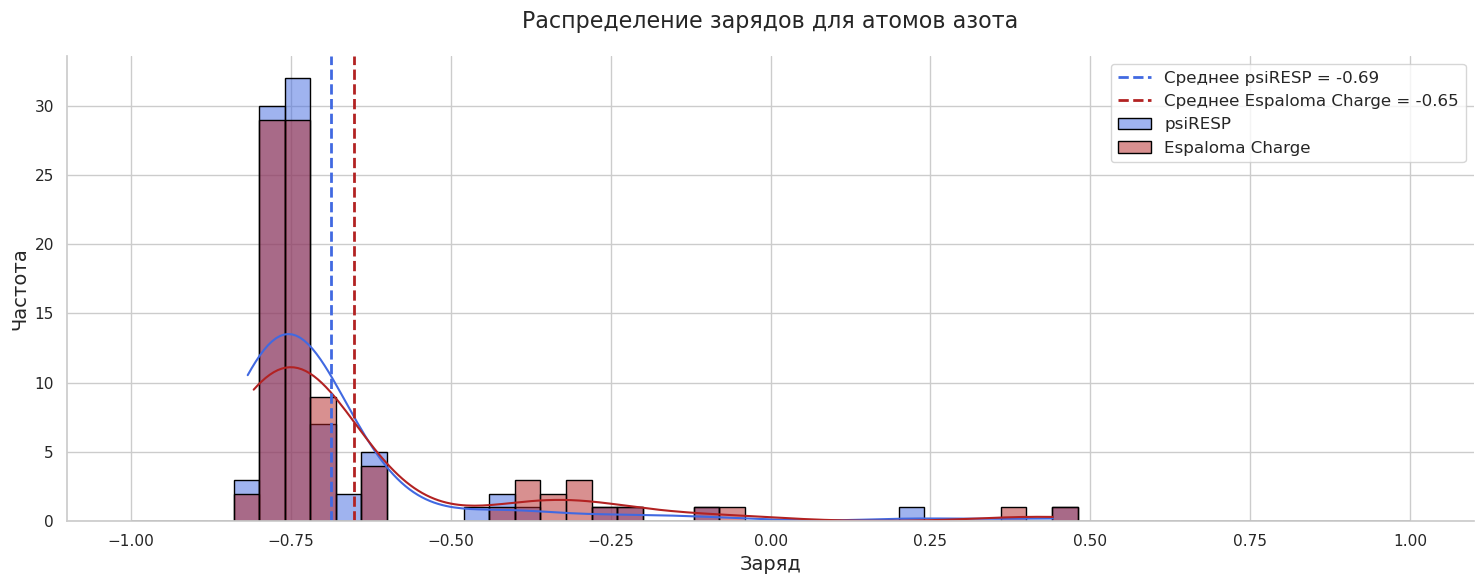

In [23]:
sns.set(style="whitegrid")
plt.figure(figsize=(15, 6))

# Построение гистограмм для атомов азота
sns.histplot(N_RDKIT_list, bins=50, binrange=(-1, 1), color='royalblue', label='psiRESP', kde=True, edgecolor='black')
sns.histplot(N_openff_list, bins=50, binrange=(-1, 1), color='firebrick', label='Espaloma Charge', kde=True, edgecolor='black')

# Добавление заголовка и подписей
plt.title('Распределение зарядов для атомов азота', fontsize=16, pad=20)
plt.xlabel('Заряд', fontsize=14)
plt.ylabel('Частота', fontsize=14)

# Вывод средних значений на графике
mean_rdk_n = np.mean(N_RDKIT_list)
mean_open_n = np.mean(N_openff_list)

plt.axvline(mean_rdk_n, color='royalblue', linestyle='--', linewidth=2, label=f'Среднее psiRESP = {mean_rdk_n:.2f}')
plt.axvline(mean_open_n, color='firebrick', linestyle='--', linewidth=2, label=f'Среднее Espaloma Charge = {mean_open_n:.2f}')

# Легенда
plt.legend(fontsize=12)

# Улучшение отображения
sns.despine()  # Убираем лишние линии
plt.tight_layout()  # Автоматическая настройка отступов

# Показать график
plt.show()

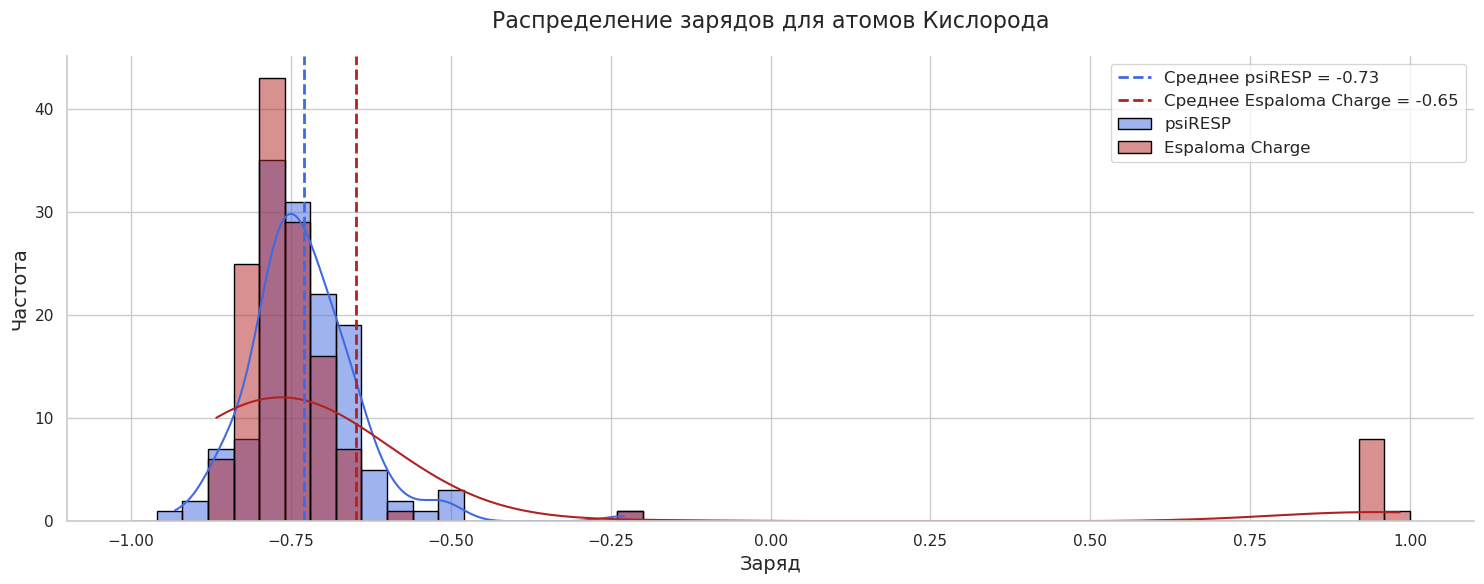

In [24]:
sns.set(style="whitegrid")
plt.figure(figsize=(15, 6))

# Построение гистограмм для атомов азота
sns.histplot(O_RDKIT_list, bins=50, binrange=(-1, 1), color='royalblue', label='psiRESP', kde=True, edgecolor='black')
sns.histplot(O_openff_list, bins=50, binrange=(-1, 1), color='firebrick', label='Espaloma Charge', kde=True, edgecolor='black')

# Добавление заголовка и подписей
plt.title('Распределение зарядов для атомов Кислорода', fontsize=16, pad=20)
plt.xlabel('Заряд', fontsize=14)
plt.ylabel('Частота', fontsize=14)

# Вывод средних значений на графике
mean_rdk_o = np.mean(O_RDKIT_list)
mean_open_o = np.mean(O_openff_list)

plt.axvline(mean_rdk_o, color='royalblue', linestyle='--', linewidth=2, label=f'Среднее psiRESP = {mean_rdk_o:.2f}')
plt.axvline(mean_open_o, color='firebrick', linestyle='--', linewidth=2, label=f'Среднее Espaloma Charge = {mean_open_o:.2f}')

# Легенда
plt.legend(fontsize=12)

# Улучшение отображения
sns.despine()  # Убираем лишние линии
plt.tight_layout()  # Автоматическая настройка отступов

# Показать график
plt.show()

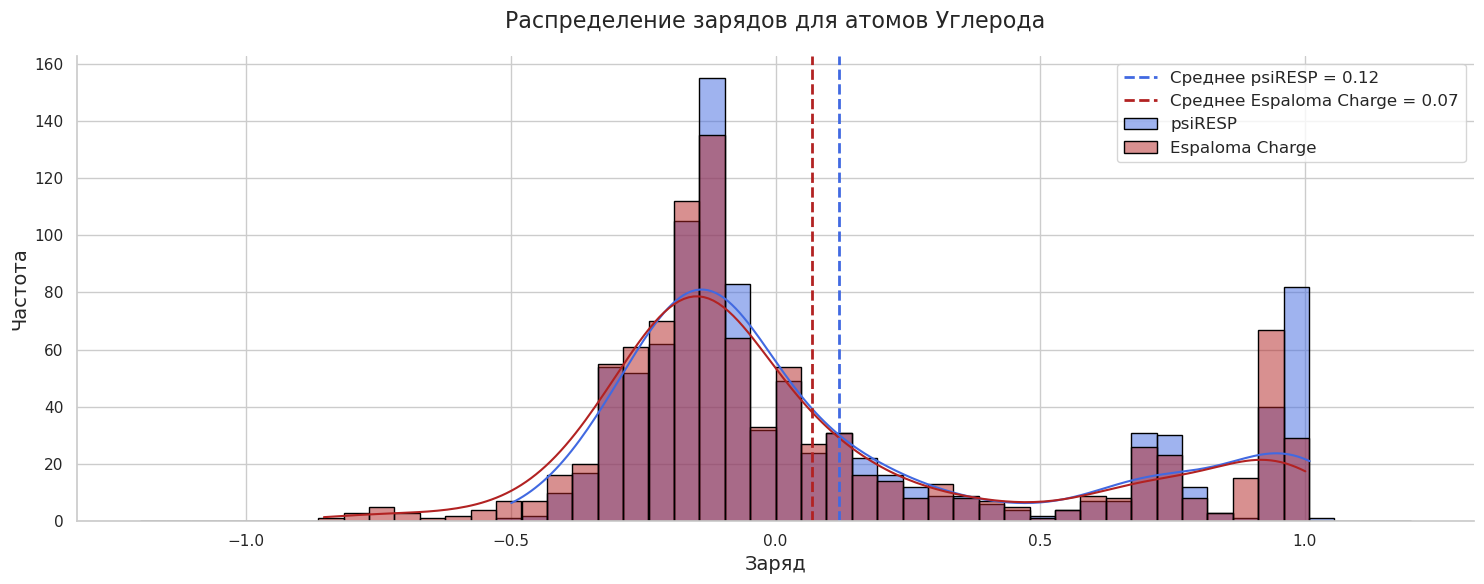

In [25]:
sns.set(style="whitegrid")
plt.figure(figsize=(15, 6))

# Построение гистограмм для атомов азота
sns.histplot(C_RDKIT_list, bins=50, binrange=(-1.2, 1.2), color='royalblue', label='psiRESP', kde=True, edgecolor='black')
sns.histplot(C_openff_list, bins=50, binrange=(-1.2, 1.2), color='firebrick', label='Espaloma Charge', kde=True, edgecolor='black')

# Добавление заголовка и подписей
plt.title('Распределение зарядов для атомов Углерода', fontsize=16, pad=20)
plt.xlabel('Заряд', fontsize=14)
plt.ylabel('Частота', fontsize=14)

# Вывод средних значений на графике
mean_rdk_с = np.mean(C_RDKIT_list)
mean_open_с = np.mean(C_openff_list)

plt.axvline(mean_rdk_с, color='royalblue', linestyle='--', linewidth=2, label=f'Среднее psiRESP = {mean_rdk_с:.2f}')
plt.axvline(mean_open_с, color='firebrick', linestyle='--', linewidth=2, label=f'Среднее Espaloma Charge = {mean_open_с:.2f}')

# Легенда
plt.legend(fontsize=12)

# Улучшение отображения
sns.despine()  # Убираем лишние линии
plt.tight_layout()  # Автоматическая настройка отступов

# Показать график
plt.show()

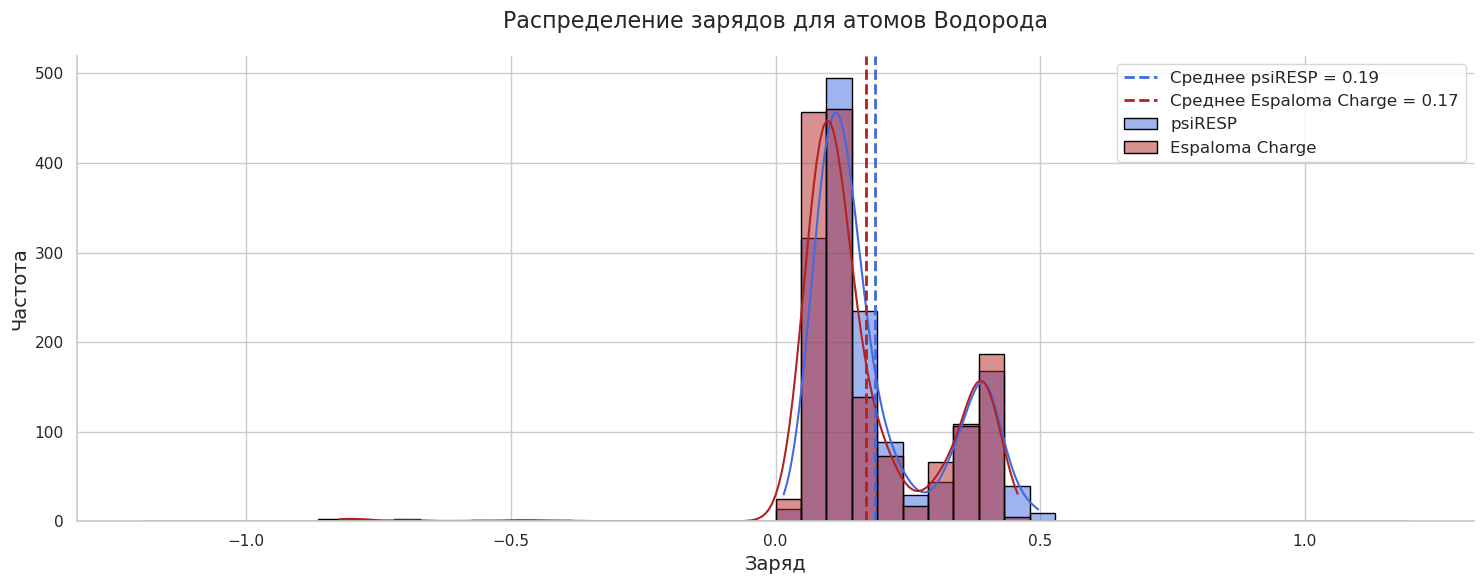

In [27]:
sns.set(style="whitegrid")
plt.figure(figsize=(15, 6))

# Построение гистограмм для атомов азота
sns.histplot(H_RDKIT_list, bins=50, binrange=(-1.2, 1.2), color='royalblue', label='psiRESP', kde=True, edgecolor='black')
sns.histplot(H_openff_list, bins=50, binrange=(-1.2, 1.2), color='firebrick', label='Espaloma Charge', kde=True, edgecolor='black')

# Добавление заголовка и подписей
plt.title('Распределение зарядов для атомов Водорода', fontsize=16, pad=20)
plt.xlabel('Заряд', fontsize=14)
plt.ylabel('Частота', fontsize=14)

# Вывод средних значений на графике
mean_rdk_h = np.mean(H_RDKIT_list)
mean_open_h = np.mean(H_openff_list)

plt.axvline(mean_rdk_h, color='royalblue', linestyle='--', linewidth=2, label=f'Среднее psiRESP = {mean_rdk_h:.2f}')
plt.axvline(mean_open_h, color='firebrick', linestyle='--', linewidth=2, label=f'Среднее Espaloma Charge = {mean_open_h:.2f}')

# Легенда
plt.legend(fontsize=12)

# Улучшение отображения
sns.despine()  # Убираем лишние линии
plt.tight_layout()  # Автоматическая настройка отступов

# Показать график
plt.show()

In [128]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_charge_distribution(df, molecule_index):
    """
    Визуализирует распределение зарядов атомов для конкретной молекулы.
    
    Параметры:
    df - DataFrame с данными о молекулах и их зарядах
    molecule_index - индекс строки в DataFrame для анализа
    """
    # Получаем данные для выбранной молекулы
    mol_data = df.iloc[molecule_index]
    
    # Определяем список атомов и их индексы
    atoms = ['N', 'O', 'C', 'H']
    
    # Формируем DataFrame для визуализации
    dfs = []
    
    # Собираем данные по атомам
    for atom_type in atoms:
        openff_values = mol_data[f'{atom_type}_OPENFF']
        rdkit_values = mol_data[f'{atom_type}_RDKIT']
        
        if isinstance(openff_values, list) and isinstance(rdkit_values, list):
            charges_data = []
            methods = []
            
            for charge_off, charge_rdkit in zip(openff_values, rdkit_values):
                charges_data.append(charge_off)
                methods.append('openff')
                charges_data.append(charge_rdkit)
                methods.append('rdkit')
            
            # Создаем DataFrame для текущего типа атома
            atom_df = pd.DataFrame({
                'Atom': [atom_type] * len(charges_data),
                'Charge': charges_data,
                'Method': methods
            })
            dfs.append(atom_df)
    
    # Объединяем DataFrames для всех типов атомов
    if dfs:
        plot_df = pd.concat(dfs, ignore_index=True)
    else:
        plot_df = pd.DataFrame(columns=['Atom', 'Charge', 'Method'])
    
    # Вычисляем суммы зарядов для каждого метода
    openff_sum = mol_data['openff_total_charge']
    rdkit_sum = mol_data['rdkit_total_charge']
    
    # Создаем график
    plt.figure(figsize=(10, 6))
    sns.swarmplot(data=plot_df, x='Atom', y='Charge', hue='Method', 
                 palette={'openff': 'firebrick', 'rdkit': 'royalblue'})
    
    # Добавляем вертикальные линии для суммы зарядов
    plt.axhline(openff_sum, color='firebrick', linestyle='--', linewidth=2, label=f'Sum OpenFF = {openff_sum:.2f}')
    plt.axhline(rdkit_sum, color='royalblue', linestyle='--', linewidth=2, label=f'Sum RDKit = {rdkit_sum:.2f}')
    
    plt.title(f'Distribution of charges for molecule {molecule_index}')
    plt.legend(title='Method')
    plt.show()

# Пример использования:
# plot_charge_distribution(your_dataframe, 0)  # для первой молекулы в DataFrame

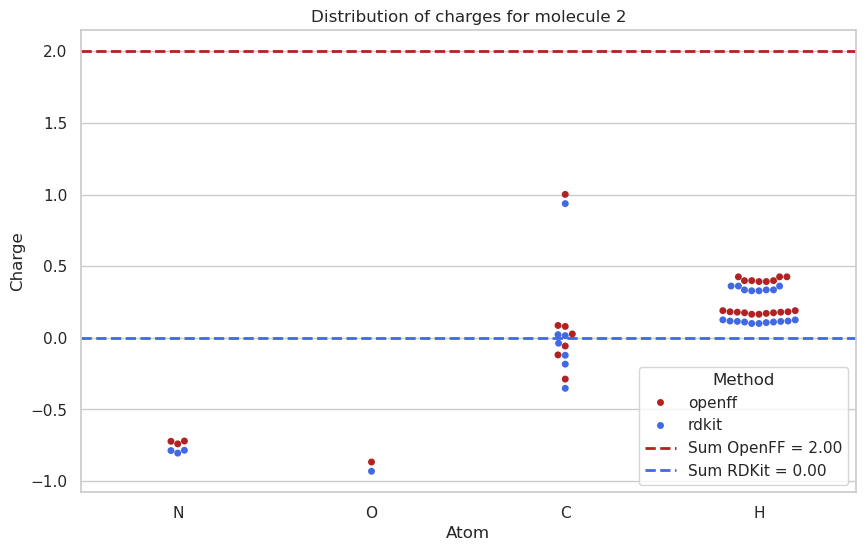

In [129]:
plot_charge_distribution(df, 2)  # для первой молекулы в DataFrame

In [125]:
print(df['openff_charges'][2], df['rdkit_charges'][2], sep='\n')

[-0.7403258188597618, 0.02682545492725988, -0.11933961054009776, 0.07949249157982488, -0.7224672540060936, 0.08623887310104986, -0.057348433040803476, -0.28799436529797895, -0.7205425008170067, 1.0010141030915323, -0.8668714269034324, -0.8864967926375328, 0.398989905513102, 0.398989905513102, 0.398989905513102, 0.18959565917330404, 0.18959565917330404, 0.1814732224710526, 0.1814732224710526, 0.17891973713713308, 0.17891973713713308, 0.39262076178866046, 0.39262076178866046, 0.17465734193401952, 0.17465734193401952, 0.1644516632922234, 0.1644516632922234, 0.17050879905300756, 0.42563333073931353, 0.42563333073931353, 0.42563333073931353]
[-0.804841935634613, -0.0376906618475914, -0.18385572731494904, 0.014976374804973602, -0.7869833707809448, 0.021722756326198578, -0.12186454981565475, -0.3525104820728302, -0.7850586175918579, 0.9364979863166809, -0.9313875436782837, -0.951012909412384, 0.33447378873825073, 0.33447378873825073, 0.33447378873825073, 0.12507954239845276, 0.125079542398452

In [114]:
df

,Unnamed: 0,Molecule_Name,2D_Image,smiles,Has_Charged_Atoms,Total_Charge,Num_Atoms,Atom_Types,openff_charges,openff_total_charge,rdkit_charges,rdkit_total_charge,N_indices,O_indices,C_indices,H_indices,N_OPENFF,N_RDKIT,O_OPENFF,O_RDKIT,C_OPENFF,C_RDKIT,H_OPENFF,H_RDKIT
0,0,CHEBI:138619,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",N1(C=2C(=C(N=CN2)N)N=C1)[C@@H]3O[C@H](COP([O-]...,True,0,28,"C,N,O,P","[-0.3177319568522433, 0.37063856898470127, -0....",-0.0,"[-0.38103342056274414, 0.4075902998447418, -0....",-0.0,[21],[16],"[1, 2, 3, 5, 9, 10, 12, 13, 18, 19, 20, 24, 25]","[28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 3...",[-0.8010073405631045],[-0.8003097176551819],[-0.6830861669905642],[-0.6819493770599365],"[0.37063856898470127, -0.22015071929769314, 0....","[0.4075902998447418, -0.2008173167705536, 0.63...","[0.15811159192247592, 0.2791085737816831, 0.27...","[0.1623525768518448, 0.28193721175193787, 0.28..."
1,1,CHEBI:57511,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",[H][C@]12SCC(COC(C)=O)=C(N1C(=O)[C@H]2NC(=O)CC...,True,-1,28,"C,N,O,S","[0.11585274195143332, -0.010888911356839042, -...",-1.0,"[0.009944425895810127, -0.0873807966709137, -0...",-0.0,[21],"[23, 26]","[0, 2, 3, 4, 6, 7, 9, 11, 13, 15, 17, 18, 19, ...","[28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 3...",[-0.3347511156850184],[-0.7579443454742432],"[0.9353608921713507, 0.9394903615660345]","[-0.7787635326385498, -0.7190758585929871]","[0.11585274195143332, -0.10821409667065988, -0...","[0.009944425895810127, -0.05742097645998001, 0...","[-0.7031725808434809, 0.08773745452829947, 0.0...","[0.13668608665466309, 0.10857076942920685, 0.1..."
2,2,CHEBI:65070,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",[NH3+]CCC[NH2+]CC[C@H]([NH3+])C([O-])=O,True,2,12,"C,N,O","[-0.7403258188597618, 0.02682545492725988, -0....",2.0,"[-0.804841935634613, -0.0376906618475914, -0.1...",0.0,"[0, 4, 8]",[10],"[1, 2, 3, 5, 6, 7, 9]","[12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 2...","[-0.7403258188597618, -0.7224672540060936, -0....","[-0.804841935634613, -0.7869833707809448, -0.7...",[-0.8668714269034324],[-0.9313875436782837],"[0.02682545492725988, -0.11933961054009776, 0....","[-0.0376906618475914, -0.18385572731494904, 0....","[0.398989905513102, 0.398989905513102, 0.39898...","[0.33447378873825073, 0.33447378873825073, 0.3..."
3,3,CHEBI:73939,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",[H][C@@]12CC[C@H](N1C(=O)C2)C([O-])=O,True,-1,11,"C,N,O","[0.12330308894773848, -0.059105174027775466, -...",-1.0,"[-0.00647356454282999, -0.13554389774799347, -...",0.0,False,[9],"[0, 1, 2, 3, 5, 7, 8]","[11, 12, 13, 14, 15, 16, 17, 18]",False,False,[0.9214084480251921],[-0.7309945821762085],"[0.12330308894773848, -0.059105174027775466, -...","[-0.00647356454282999, -0.13554389774799347, -...","[-0.7842794324908602, 0.09881635348459608, 0.0...","[0.17593468725681305, 0.15144793689250946, 0.1..."
4,4,CHEBI:63137,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",OC1C[NH2+]C(C1)C([O-])=O,True,0,9,"C,N,O","[-0.714443093786637, 0.18494760369261107, 0.06...",0.0,"[-0.7144430875778198, 0.18494760990142822, 0.0...",0.0,[3],[7],"[1, 2, 4, 5, 6]","[9, 10, 11, 12, 13, 14, 15, 16, 17]",[-0.7108471455673376],[-0.7108471393585205],[-0.771406120310227],[-0.7714061141014099],"[0.18494760369261107, 0.06495446090896924, -0....","[0.18494760990142822, 0.06495446711778641, -0....","[0.42510252570112544, 0.11836391066511472, 0.1...","[0.4251025319099426, 0.11836391687393188, 0.19..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,CHEBI:167053,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",C=1(C=CC(=C2C1N=C3C(=N2)C=CC=C3C(=O)[O-])COC(=...,True,0,26,"C,N,O","[0.2896679669272068, -0.378109362756097, -0.17...",0.0,"[0.2896679639816284, -0.3781093657016754, -0.1...",-0.0,[23],[16],"[0, 1, 2, 3, 4, 5, 7, 8, 10, 11, 12, 13, 14, 1...","[26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 3...",[-0.7763722509492276],[-0.7763722538948059],[-